<a href="https://colab.research.google.com/github/eacasas/algoritmosOptimizacion/blob/main/EfraimCasas_TrabajoPr%C3%A1ctico_Algoritmos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Seminario<br>
Nombre y Apellidos: Efraím Alberto Casas Herrera  <br>
Url: https://colab.research.google.com/drive/1oXz50K2Qg18VovnWeNPCkqgBAlZtGgYu?usp=sharing <br>
Problema:
>2. Organizar los horarios de partidos de La Liga<br>

Descripción del problema: Desde la La Liga de fútbol profesional se pretende organizar los horarios de los partidos de
liga de cada jornada. Se conocen algunos datos que nos deben llevar a diseñar un
algoritmo que realice la asignación de los partidos a los horarios de forma que maximice la
audiencia. 





                                        


**¿Cuantas posibilidades hay sin tener en cuenta las restricciones?**  


Si tenemos 10 partidos y 10 horarios posibles la cantidad de posibilidades sería 10! es decir 3,628,800 posibilidades. Si cada partido se juega en un horario diferente. Sin la resticciones. 

<br>

**¿Cuantas posibilidades hay teniendo en cuenta todas las restricciones?**

Hay dos restrcciones importantes a tener en cuenta:
1. Se debe garantizar que dos (Viernes y Lunes) partidos siempre se jueguen. 
2. Es posible que varios partidos se jueguen en un mismo horario, teniendo en cuentas la restricción anterior. 

Para este casi habria que sacar la probabilidad e jugar 8 partidos en 8 horarios, con la posibilidad de que en un horario se puedan jugar varios partidos. 

(2^8)^8 = 429.4967.296
este resultado se multiplicaria por 2 que son las dos posibilidades de los partidos del viernes y domingo, los cuales tendrían dos opciones de jugarse. 







**Modelo para el espacio de soluciones**

<br>
(*) ¿Cual es la estructura de datos que mejor se adapta al problema? Argumentalo.(Es posible que hayas elegido una al principio y veas la necesidad de cambiar, arguentalo)


Respuesta : La estructura de datos que utilicé es un dataframe de pandas. para crear premutaciones y aleatoriedad, convertia partes del dataframe de pandas a listas nativas de Python. 

Utilicé el Dataframe de pandas porque existe un número  mediano de información de cada jornada que es relevante para el problema y que tiene formato diferentes y utilizar diccionarios podría ser un poco más complejo. El horario es un texto, las ponderaciones son float, el partido es una tupla. 
Entonces por mi experencia consideré que un Dataframe era el que mejor iba a manejar la estructura de los datos, de forma más organizada. 
Otra opción habría sido numpy o diccionario de datos, pero por al tener tipos de datos difentes consideré que pandas era la mejor opción.

**Según el modelo para el espacio de soluciones**
<br>
(*)¿Cual es la función objetivo?

(*)¿Es un problema de maximización o minimización?

Respuesta: 
Es tes un problema de máximización, la idea es poder maximizar el número de audiencia.

La función obejetivos es:

Sumatoria de: AudienciaBase * PonderaciónHorarios * (1-coincidencia)

Para todos lo encuentros de la jornada


**Diseña un algoritmo para resolver el problema por fuerza bruta**

Respuesta: Para diseñar un algoritmo de fuerzar bruta es necesario crear todas la combinaciones posibles entre horarios y juegos, para luego evaluar cada una las posibles soluciones y escoger la que mayor audiencia potencial brinde. Cómo veremos a continuación, es posible generar una buena solución con pequeño -comparativamente- número de soluciones. Por ese motico no se ve necesario generar un algoritmo por fueza bruta.

Calcula la complejidad del algoritmo por fuerza bruta



Respuesta 

La complejidad del algoritmo de fuerza bruta es: O(n!)

# Diseño de algoritmo Metaheurístico

## 1. Carga de datos iniciales 

a). A continuación se va a realizar la carga de los equipos con sus respectivas categorias, para efectos de practicidad y agilidad se agregó una nueva columna llamada index_cat: Esta es un equivalentes entre la categoría y el número de indice, para luego dar agilidad en las busquedas de las audiencias. A=0; B=1; C=2.

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import random

In [6]:
#Esta es una dataframe global que se utilizará para almacenar los resultados de las iteraciones y su audiencia
resultados = pd.DataFrame(columns=['n','metodo','audiencia'])

In [7]:
#Se importa el csv, con los equipos y categorpias. Siguiendo las restricciones del problema. 
#3 equipos en la categoría A, 11 equipos de categoría B y 6 equipos de categoría C.
teamCategory=pd.read_csv('/content/sample_data/TeamCategory.csv')
teamCategory['category'] = teamCategory['category'].astype("string")
display(teamCategory)



,team,category,index_cat
0,Real Madrid,A,0
1,Barcelona,A,0
2,Atletico,A,0
3,Celta,B,1
4,Valencia,B,1
5,R. Sociedad,B,1
6,Athletic,B,1
7,Villareal,B,1
8,Alaves,B,1
9,Levante,B,1


Se definirá un diccionarío con la información de los horarios y su ponderación, esta contiene el horario en la columna schedule y su coeficiente en la columna coeff

In [8]:
#Se crea un diccionario con la información de los horarios
dicSchedulePon = { "schedule" : ["V20","S12","S16", "S18","S20","D12","D16", "D18","D20","L20"], 
                    "coeff" : [0.4,0.55,0.7, 0.8,1,0.45,0.75,0.85,1,0.4]}
schedulePon = pd.DataFrame(dicSchedulePon)

display(schedulePon)

,schedule,coeff
0,V20,0.40
1,S12,0.55
2,S16,0.70
3,S18,0.80
4,S20,1.00
5,D12,0.45
6,D16,0.75
7,D18,0.85
8,D20,1.00
9,L20,0.40


Se definirá la matriz de audiencia, según la condiciones dada

In [9]:
audienceMatrix = [[2,   1.3,    1],
                  [1.3, 0.9,  0.75],
                  [1,   0.75, 0.47]]

## 2. Generador de partidos aleatorios

Para probar la efectividad el algoritmo vamos a realizar un artefacto generador de todos los partidos de una joranada, con su ponderación de audiencia según la matriz de audiencia.

In [10]:
#Se generan tuplas aleatorias 
def match_pairs(df):
    elements = df['team'].tolist()
    random.shuffle(elements)
    return list(zip(elements[::2], elements[1::2]))

In [11]:
result = match_pairs(teamCategory)
print(result)

[('Valladolid', 'Real Madrid'), ('Español', 'Getafe'), ('Leganes', 'Betis'), ('Valencia', 'Barcelona'), ('Athletic', 'Granada'), ('Villareal', 'Osasuna'), ('Alaves', 'Eibar'), ('Celta', 'Mallorca'), ('R. Sociedad', 'Atletico'), ('Levante', 'Sevilla')]




Ya tenemos una función capaz de generar todos los partidos de una jornada de forma aleatoria. Ahora completaremos la información de cada encuento con la categoría de los equipos y la base de audiencia.


In [190]:
def generate_maths(teamCategory):
  journey = pd.DataFrame(columns=['match','category','base_m'])
  for matchJ in result:
      #Se trae la información delos equipos
      teamInfo0 = teamCategory[teamCategory['team']==matchJ[0]]
      teamInfo1 = teamCategory[teamCategory['team']==matchJ[1]]
      #Se consultan las categorias
      category0, category1 = teamInfo0['category'].tolist()[0], teamInfo1['category'].tolist()[0]
      #Se consulta el indice
      index0, index1 = int(teamInfo0['index_cat']), int(teamInfo1['index_cat'])
      base = audienceMatrix[index0][index1]

      new_row = {'match':matchJ,'category': (category0, category1) ,'base_m':base}
      journey=journey.append(new_row,ignore_index=True)

  return journey

In [191]:
print(generate_maths(teamCategory))

                       match category base_m
0  (Valladolid, Real Madrid)   (C, A)      1
1          (Español, Getafe)   (B, B)    0.9
2           (Leganes, Betis)   (C, B)   0.75
3      (Valencia, Barcelona)   (B, A)    1.3
4        (Athletic, Granada)   (B, C)   0.75
5       (Villareal, Osasuna)   (B, C)   0.75
6            (Alaves, Eibar)   (B, C)   0.75
7          (Celta, Mallorca)   (B, C)   0.75
8    (R. Sociedad, Atletico)   (B, A)    1.3
9         (Levante, Sevilla)   (B, B)    0.9


Guardamos el resultado con el fin de trabajar con los mismos datos durante todo el ejercicio.

In [13]:
#Guardamos la jornada

journey.to_csv('/content/sample_data/journey2.csv', sep=';', index = True)

## 3. Optimización

A continuación vamos a generar un algorimo de optimización meta heurisco con el fin de optimizar y buscar una solución adecuada de horarios de televisión para la jornada.

In [14]:
#Cargamos una jornada generada anteriormente

journey1 = pd.read_csv('/content/sample_data/journey1.csv', sep=';')
journey1.columns = ['id_match','match', 'category', 'base_m']
display(journey1)

,id_match,match,category,base_m
0,0,"('Alaves', 'Betis')","('B', 'B')",0.90
1,1,"('Barcelona', 'Atletico')","('A', 'A')",2.00
2,2,"('Levante', 'Valladolid')","('B', 'C')",0.75
3,3,"('Español', 'Real Madrid')","('B', 'A')",1.30
4,4,"('Osasuna', 'Eibar')","('C', 'C')",0.47
5,5,"('Mallorca', 'Celta')","('C', 'B')",0.75
6,6,"('R. Sociedad', 'Athletic')","('B', 'B')",0.90
7,7,"('Granada', 'Valencia')","('C', 'B')",0.75
8,8,"('Leganes', 'Villareal')","('C', 'B')",0.75
9,9,"('Sevilla', 'Getafe')","('B', 'B')",0.90


A continuación vamos a realizar el proceso de optimización por diferentes técnicas heurísticas para encontrar una solución que máximice la audiencia de cada una jornada

### 3.1 Busqueda aleatoria

A continuación se define una función para generar una programación aleatoría. 

In [214]:
def generate_schedule(journey,schedulePon):
    #se copia la jornada con el fin de agregar los nuevos campos
    journeyfull = journey.copy()
    journeyfull['schedule']=''
    journeyfull['ponde']=0   
    journey['id_match']=journey.index

    #Se convierten a lista con el objetivo de hace la combinacion aleatoria entre encuentros y horarios
    journey = journey['id_match'].tolist()
    schedulePonL = schedulePon['schedule'].tolist()
    #Se agitan las listas para cambiar su orden
    random.shuffle(journey)
    random.shuffle(schedulePonL)
    #Se crean las parejas
    schedule = list(zip(journey, schedulePonL))

    for matchS in schedule:
        #Se extrae la información del horario, para traer la ponderación correspondiente
        #Match[0] = identificador del partido: 0 -> (Alaves vs Betis)
        #Match[1] = horario del partivo: V20
        coeff = float(schedulePon.loc[schedulePon['schedule'] == matchS[1], 'coeff'].iloc[0])
        #Se actualiza la ponderación
        journeyfull.loc[int(matchS[0]),'ponde'] = coeff
        #Se actualiza el horario
        journeyfull.loc[int(matchS[0]),'schedule'] = matchS[1]

    journeyfull['base_ponde']= journeyfull['base_m']*journeyfull['ponde']
    journeyfull['concidence']= 1 #Contiene el factor de multiplicación
    journeyfull['total'] = journeyfull['base_ponde']*journeyfull['concidence']

    return journeyfull

**descripcion del dataframe**

**id_match**: Identificador del partido

**match**: Equipos enfrentados

**category**: categoria de los equipos enfrentados

**base_m**: Base de audiencia en millones

**schedule**: Horario programado

**ponde**: Ponderación del horario

**base_ponde**: Base de auduencia x ponderación de horario

**coincidence**: Ponderación por coincidencia

**total**: base_ponde x coincidence

In [16]:
firstSche = generate_schedule(journey1,schedulePon)

display(firstSche)

,id_match,match,category,base_m,schedule,ponde,base_ponde,concidence,total
0,0,"('Alaves', 'Betis')","('B', 'B')",0.90,S20,1.00,0.9000,1,0.9000
1,1,"('Barcelona', 'Atletico')","('A', 'A')",2.00,D20,1.00,2.0000,1,2.0000
2,2,"('Levante', 'Valladolid')","('B', 'C')",0.75,D12,0.45,0.3375,1,0.3375
3,3,"('Español', 'Real Madrid')","('B', 'A')",1.30,D16,0.75,0.9750,1,0.9750
4,4,"('Osasuna', 'Eibar')","('C', 'C')",0.47,V20,0.40,0.1880,1,0.1880
5,5,"('Mallorca', 'Celta')","('C', 'B')",0.75,S18,0.80,0.6000,1,0.6000
6,6,"('R. Sociedad', 'Athletic')","('B', 'B')",0.90,S12,0.55,0.4950,1,0.4950
7,7,"('Granada', 'Valencia')","('C', 'B')",0.75,S16,0.70,0.5250,1,0.5250
8,8,"('Leganes', 'Villareal')","('C', 'B')",0.75,D18,0.85,0.6375,1,0.6375
9,9,"('Sevilla', 'Getafe')","('B', 'B')",0.90,L20,0.40,0.3600,1,0.3600


In [17]:
audiencia_first = sum(firstSche['total'])
print(f'Audiencia: {audiencia_first} ')

Audiencia: 7.018000000000001 


A continuación definiremos la busqueda aleatoria que se encargará de encontrar la mejor solución dentro de una población de soluciones aleatorias.

In [208]:
def busqueda_aleatoria(journey,n,resultados=None):

    if type(resultados) != pd.DataFrame:
      resultados = pd.DataFrame(columns=['n','metodo','audiencia'])

    best_schedules = None
    best_audience = 0

    for i in range(n):
        temp_schedule = generate_schedule(journey,schedulePon)   #Se genera una programación aleatoria
        temp_audience = sum(temp_schedule['total'])          #Se calcula la audiencia de la solución candidata
        #print(f'temp_audience: {temp_audience}')
        if temp_audience > best_audience:
            best_schedules = temp_schedule
            best_audience = temp_audience

            #agregamos la información al dataframe de resultados para graficar el avance del algoritmo
            new_row = {'n':len(resultados)+1, 'metodo':'Aleatoria','audiencia':best_audience}
            resultados= resultados.append(new_row, ignore_index=True)

    return best_schedules,resultados

In [234]:
#Buscamos una solución base, generando 10 combianciones de partido y horarios 
base_schedule, resultados = busqueda_aleatoria (journey1,10)

In [235]:
audiencia = sum(base_schedule['total'])
print(f'Audiencia Potencial: {audiencia} ')

Audiencia Potencial: 7.044 


In [21]:
display(base_schedule)

,id_match,match,category,base_m,schedule,ponde,base_ponde,concidence,total
0,0,"('Alaves', 'Betis')","('B', 'B')",0.90,S18,0.80,0.7200,1,0.7200
1,1,"('Barcelona', 'Atletico')","('A', 'A')",2.00,D16,0.75,1.5000,1,1.5000
2,2,"('Levante', 'Valladolid')","('B', 'C')",0.75,S20,1.00,0.7500,1,0.7500
3,3,"('Español', 'Real Madrid')","('B', 'A')",1.30,S16,0.70,0.9100,1,0.9100
4,4,"('Osasuna', 'Eibar')","('C', 'C')",0.47,D12,0.45,0.2115,1,0.2115
5,5,"('Mallorca', 'Celta')","('C', 'B')",0.75,S12,0.55,0.4125,1,0.4125
6,6,"('R. Sociedad', 'Athletic')","('B', 'B')",0.90,L20,0.40,0.3600,1,0.3600
7,7,"('Granada', 'Valencia')","('C', 'B')",0.75,V20,0.40,0.3000,1,0.3000
8,8,"('Leganes', 'Villareal')","('C', 'B')",0.75,D18,0.85,0.6375,1,0.6375
9,9,"('Sevilla', 'Getafe')","('B', 'B')",0.90,D20,1.00,0.9000,1,0.9000


Mediante la busqueda aleatoria ya tenemos una solución base que nos permitirá seguir optimizando la programación de la jornada. 




### 3.2 Busqueda local


La busqueda local realizará la busqueda de una buena solución tiendo como base, la programación generada anteriormente mediantes busqueda aleatoria. Para esto intercambiará dos nodos y validará si es una buena solución o no.



In [163]:
def busqueda_local(journey, resultados = None):

    if type(resultados) != pd.DataFrame:
      resultados = pd.DataFrame(columns=['n','metodo','audiencia'])

    journey = journey.copy()
    best_schedules = journey.copy()
    best_audience = sum(best_schedules['total'])

    for i in range(len(journey)-2):
        for j in range(i+1, len(journey)-1):
            #print(f'intercambio {i} , {j}')
            #intercambiamos horarios
            temp=journey.loc[i,'schedule']
            journey.loc[i,'schedule'] = journey.loc[j,'schedule']
            journey.loc[j,'schedule'] = temp

            #intercambiamos ponderación
            temp = journey.loc[i,'ponde']
            journey.loc[i,'ponde'] = journey.loc[j,'ponde']
            journey.loc[j,'ponde'] = temp            

            #Recalculamos los valores
            journey['base_ponde'] = journey['base_m']*journey['ponde']
            journey['concidence'] = 1
            journey['total'] = journey['base_ponde']*journey['concidence']

            temp_audience = sum(journey['total'])          #Se calcula la audiencia de la solución candidata
            #print(f'Audiencia: {temp_audience}')      

            if temp_audience > best_audience:
                best_schedules = journey.copy()
                best_audience = temp_audience

                #agregamos la información al dataframe de resultados para graficar el avance del algoritmo
                new_row = {'n':len(resultados)+1, 'metodo':'Local','audiencia':best_audience}
                resultados= resultados.append(new_row, ignore_index=True)
           
    return best_schedules, resultados

In [236]:
## Lamamos la busqueda local
print('Audiencia Inicial: ' + str(sum(base_schedule['total'])))
local_schedule, r = busqueda_local(base_schedule)
print('Audiencia Local: ' + str(sum(local_schedule['total'])))

Audiencia Inicial: 7.044
Audiencia Local: 7.1555


In [237]:
display(local_schedule)

,id_match,match,category,base_m,schedule,ponde,base_ponde,concidence,total
0,0,"('Alaves', 'Betis')","('B', 'B')",0.90,S18,0.80,0.7200,1,0.7200
1,1,"('Barcelona', 'Atletico')","('A', 'A')",2.00,S20,1.00,2.0000,1,2.0000
2,2,"('Levante', 'Valladolid')","('B', 'C')",0.75,V20,0.40,0.3000,1,0.3000
3,3,"('Español', 'Real Madrid')","('B', 'A')",1.30,D20,1.00,1.3000,1,1.3000
4,4,"('Osasuna', 'Eibar')","('C', 'C')",0.47,L20,0.40,0.1880,1,0.1880
5,5,"('Mallorca', 'Celta')","('C', 'B')",0.75,D18,0.85,0.6375,1,0.6375
6,6,"('R. Sociedad', 'Athletic')","('B', 'B')",0.90,D12,0.45,0.4050,1,0.4050
7,7,"('Granada', 'Valencia')","('C', 'B')",0.75,D16,0.75,0.5625,1,0.5625
8,8,"('Leganes', 'Villareal')","('C', 'B')",0.75,S12,0.55,0.4125,1,0.4125
9,9,"('Sevilla', 'Getafe')","('B', 'B')",0.90,S16,0.70,0.6300,1,0.6300


Algo interesante es que en las diversar pruebas que se han ejecutado, siempre los partidos de equipos Clase A qudan programados para el día sábado y domingo en horario de mayor audiencia, lo cual es un comportamiento esperado y seguramente serpía una regla si estuvieramos creando un algoritmo de lógica inductiva mendiante reglas.



### 3.4 Generador de partidos simultaneos


Los métodos metaheuristicos, como búsqueda aleatoria y busqueda local, permitieron tener una solución aceptable, con un costo computacional bajo y la  cual es una buena base para aplicar otras técnicas. 

Ahora requerimos validar que sucede con la audiencia potencial de la jornado, sí jugamos varios partidos en el mismo horario, por lo cual vamos a utilzar una busqueda inductiva. Reacomodando los horarios del día sábado y domingo, a horarios de más audiencia para que se jueguen partidos en horarios simultaneos y verificar si tenemos alguna mejora en la audiencia potencial.

In [25]:
display(schedulePon)

,schedule,coeff
0,V20,0.40
1,S12,0.55
2,S16,0.70
3,S18,0.80
4,S20,1.00
5,D12,0.45
6,D16,0.75
7,D18,0.85
8,D20,1.00
9,L20,0.40


Se generará una matríz con la lista de horarios que se pueden jugar simultaneamentente, en la fila 0 estarán los horarios del día sábado y en la final 1 los horarios del domingo. 
Este arreglo nos servirá para generar partidos simultaneos en los horarios permitidos. 
Como regla lógica se llevarán los partidos en horarios de menos audiencia a horarios de más audiencia en el mismo día y se validará si la audiencia total sube, para así guardar una nueva solución.

In [145]:
def match_simultaneity(journey, resultados=None):

    if type(resultados) != pd.DataFrame:
      resultados = pd.DataFrame(columns=['n','metodo','audiencia'])

    journey = journey.copy()
    best_schedules = journey.copy()
    best_audience = sum(best_schedules['concidence'])

    schedulerSimu = [schedulePon['schedule'][1:4].tolist(),
                 schedulePon['schedule'][5:8].tolist()]

    #Se generan varías posibilidades de reptir horarios
    for schedule_days in schedulerSimu:
      max_sche = max(schedule_days)
      schedule_days_ori = schedule_days.copy()
      for i in range(len(schedule_days)-1):
        journey = best_schedules.copy()
        schedule_days = schedule_days_ori.copy()
        schedule_days[i] = max_sche

        #tenemos una combinación de fechas para el día, jugando partidos en simultaneo
        coeff = float(schedulePon.loc[schedulePon['schedule'] == schedule_days[i], 'coeff'].iloc[0])
        mask = journey['schedule'] == schedule_days_ori [i]
        journey.loc[mask, 'schedule'] = schedule_days[i]
        journey.loc[mask, 'ponde'] = coeff

        mask = journey['schedule'] == schedule_days[i]
        journey.loc[mask, 'concidence'] = 0.75

        #se sube a un horario superior en la segunda iteración
        if i == 1:
          coeff = float(schedulePon.loc[schedulePon['schedule'] == schedule_days_ori[i], 'coeff'].iloc[0])
          mask = journey['schedule'] == schedule_days_ori [0]
          journey.loc[mask, 'schedule'] = schedule_days_ori[i]
          journey.loc[mask, 'ponde'] = coeff

        #print(schedule_days)

        #Recalculamos los valores
        journey['base_ponde'] = journey['base_m']*journey['ponde']
        journey['total'] = journey['base_ponde']*journey['concidence']    

        temp_audience = sum(journey['total'])          #Se calcula la audiencia de la solución candidata
        
        #display(journey)
        #print(f'Audiencia: {temp_audience}')

        if temp_audience > best_audience:
            best_schedules = journey.copy()
            best_audience = temp_audience       

            #agregamos la información al dataframe de resultados para graficar el avance del algoritmo
            new_row = {'n':len(resultados)+1, 'metodo':'Simultanea','audiencia':best_audience}
            resultados= resultados.append(new_row, ignore_index=True)
                      
    return best_schedules, resultados

In [238]:
## Lamamos a la simultaneidad de horarios
print('Audiencia Inicial: ' + str(sum(local_schedule['total'])))
simu_schedule, resultados = match_simultaneity(local_schedule)
print('Audiencia Local: ' + str(sum(simu_schedule['total'])))
display(simu_schedule)


Audiencia Inicial: 7.1555
Audiencia Local: 7.1555


,id_match,match,category,base_m,schedule,ponde,base_ponde,concidence,total
0,0,"('Alaves', 'Betis')","('B', 'B')",0.90,S18,0.80,0.7200,1,0.7200
1,1,"('Barcelona', 'Atletico')","('A', 'A')",2.00,S20,1.00,2.0000,1,2.0000
2,2,"('Levante', 'Valladolid')","('B', 'C')",0.75,V20,0.40,0.3000,1,0.3000
3,3,"('Español', 'Real Madrid')","('B', 'A')",1.30,D20,1.00,1.3000,1,1.3000
4,4,"('Osasuna', 'Eibar')","('C', 'C')",0.47,L20,0.40,0.1880,1,0.1880
5,5,"('Mallorca', 'Celta')","('C', 'B')",0.75,D18,0.85,0.6375,1,0.6375
6,6,"('R. Sociedad', 'Athletic')","('B', 'B')",0.90,D12,0.45,0.4050,1,0.4050
7,7,"('Granada', 'Valencia')","('C', 'B')",0.75,D16,0.75,0.5625,1,0.5625
8,8,"('Leganes', 'Villareal')","('C', 'B')",0.75,S12,0.55,0.4125,1,0.4125
9,9,"('Sevilla', 'Getafe')","('B', 'B')",0.90,S16,0.70,0.6300,1,0.6300


La iteración de horarios simultaneos en este ejemplo no nos está dando bueno resultados y en varias pruebas que se hicieron no sé logró ver mejoría en la audiencia potencial, jugando varios partidos en el mismo horario.

# Solución Orquestada (annealing simulated)

Esta es la solución final, y para esta vamos a crear un algoritmo de Annealing simulado, el cual se encargará de llamar en su interior las solución de busqueda aleatoria y de busqueda local. Se realiza por este método con el fin de diversificar la solución y analizar difentes posibilidades de programación.

### Anealing Simulado 

In [224]:
def simulated_annealing(journey, schedulePon, T, alpha, schedule=None):

    #Dataframe para almacenar los resultados iniciales
    r = pd.DataFrame(columns=['n','metodo','audiencia'])
    
    #si no tenemos ningún encuentro base generamos uno
    if type(schedule) != pd.DataFrame:
      schedule,r = busqueda_aleatoria (journey,1,r)      

    #en x vamos a almacenar la mejor la programación de horarios candidata
    x = schedule

    #Audiencia
    audience = sum(x['total'])
    best_x = x
    best_audience = audience
    
    #Se agrega la audiencia inicial 
    new_row = {'n':len(r)+1, 'metodo':'Inicial','audiencia':audience}
    r= r.append(new_row, ignore_index=True)
    
    while T > 1e-3:
        # Se genera una solución aleatoria
        x_new,r = busqueda_aleatoria (journey,2,r)

        # Generamos busqueda local
        x_new,r = busqueda_local(x_new,r)

        #generamos la nueva audiencia
        new_audience = sum(x_new['total'])

        delta_audience = new_audience - audience
        if delta_audience > 0: #Si la solución tiene más audiencia
            x = x_new
            cost = new_audience                    
            if new_audience > best_audience:
                best_x = x_new
                best_audience = new_audience
        else:
            p = math.exp(-delta_audience / T)
            if random.uniform(0, 1) < p:
                #print('Diversificando')
                x = x_new
                cost = new_audience
        T = T * alpha
    return best_x,r

In [241]:
#Generamos una primera solución aleatoria.
base_schedule, r = busqueda_aleatoria (journey1,1)

# Ingresamos la temperatura, para este caso será 100mil
T = 100000
# Ingresamos la tasa de enfriamiento
alpha = 0.7

# Audiencia inicial
audiencia = sum(base_schedule['total'])
print(f'Audiencia Base del Problema: {audiencia}')

# Llamado al algoritmo para busqueda de solución
our_best_scheduler_ene, resultados = simulated_annealing(journey1, schedulePon, T, alpha, base_schedule)

#Audiencia Final
audiencia = sum(our_best_scheduler_ene['total'])
iteraciones = resultados.shape[0]
print(f'Resultado mejor audiencia potencail: {audiencia} y el número de iteraciones total fue: {iteraciones}')

#mostramos la programación final arrojada por el algoritmo
display(our_best_scheduler_ene)

Audiencia Base del Problema: 6.742999999999999
Resultado mejor audiencia potencail: 7.200499999999999 y el número de iteraciones total fue: 197


,id_match,match,category,base_m,schedule,ponde,base_ponde,concidence,total
0,0,"('Alaves', 'Betis')","('B', 'B')",0.90,D16,0.75,0.6750,1,0.6750
1,1,"('Barcelona', 'Atletico')","('A', 'A')",2.00,D20,1.00,2.0000,1,2.0000
2,2,"('Levante', 'Valladolid')","('B', 'C')",0.75,D12,0.45,0.3375,1,0.3375
3,3,"('Español', 'Real Madrid')","('B', 'A')",1.30,S20,1.00,1.3000,1,1.3000
4,4,"('Osasuna', 'Eibar')","('C', 'C')",0.47,L20,0.40,0.1880,1,0.1880
5,5,"('Mallorca', 'Celta')","('C', 'B')",0.75,V20,0.40,0.3000,1,0.3000
6,6,"('R. Sociedad', 'Athletic')","('B', 'B')",0.90,S16,0.70,0.6300,1,0.6300
7,7,"('Granada', 'Valencia')","('C', 'B')",0.75,D18,0.85,0.6375,1,0.6375
8,8,"('Leganes', 'Villareal')","('C', 'B')",0.75,S12,0.55,0.4125,1,0.4125
9,9,"('Sevilla', 'Getafe')","('B', 'B')",0.90,S18,0.80,0.7200,1,0.7200


In [228]:
#Verificacmos que el mejor resultado devuelto, haya sido el mejor de la lista de todos los resultados.
print(max(resultados['audiencia']))

7.222999999999999




### Grafica del avance 



In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

[(6.0, 8.0)]

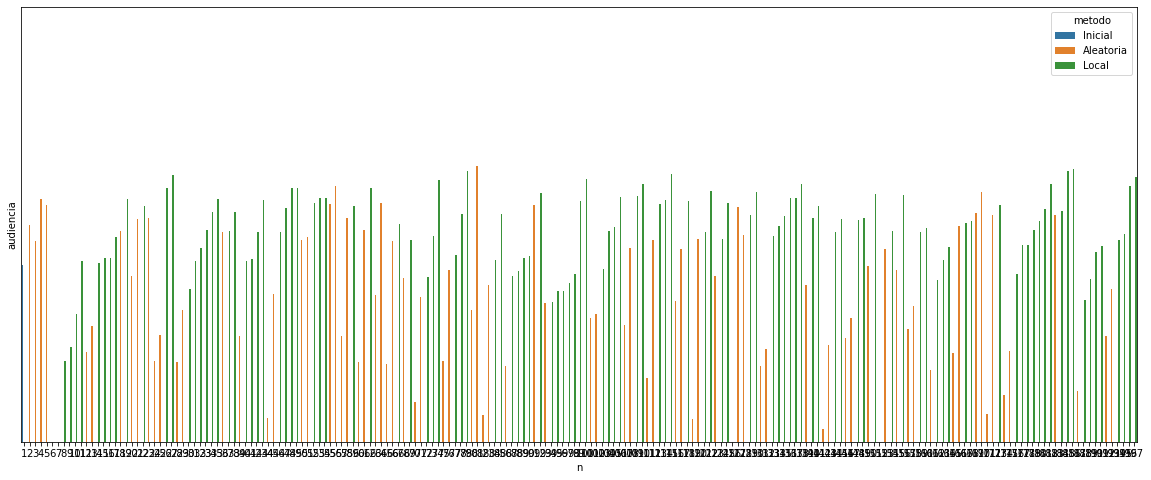

In [242]:
f, ax = plt.subplots(figsize=(20, 8))
plt.xscale('linear')
plt.yscale('log')
ax.set_yscale('symlog', linthreshy=0.5)
ax.grid()
sns.barplot(data = resultados,
             x ='n',
             y ='audiencia',
             hue='metodo'
            )
ax.set(ylim=(6, 8))

En la gráfica podemos ver cómo la busqueda local, máximiza la audiencia.

# Calcula la complejidad del algoritmo 

Respuesta: Al ser un algoritmo metaheuristico, el orden de complejidad es complejo de cálcular, pero podemos establecer que este se encuentra en el orden de los compoenente utilizados.

Orden de complejidad busqueda aleatoria= 0(n)
Orden de complejidad busqueda local = 0(n**2)

orden de complejidad Orquestador = n**2 + n
 
por ende podemos decir que el orden de complejidad de nuestro algoritmo está entre un orden de O(n**2) lo cual nos da un orden exponecial.



# Según el problema (y tenga sentido), diseña un juego de datos de entrada aleatorios

Respuesta, en el apartado incial se generó la un algoritmos para generación de paridos aleatorios. A continuación vamos a hacer el llamado del método, en varios acasiones para que nos genere la lista de encuentros y generaremos la solució propuesta por el algoritmo para ambos casos.

In [229]:
journey3= generate_maths(teamCategory)
#Presentamos la jornada inicial
print(journey3)

#generamos la solución para la jornada
schedulerJourney3, r3 = simulated_annealing(journey3, schedulePon, T, alpha)

#audiencia 
audiencia3=sum(schedulerJourney3['total'])
print(f'Resultado mejor audiencia potencial: {audiencia3} y el número de iteraciones total fue: {r3.shape[0]}')

#Configuraión de la jornada
display(schedulerJourney3)


                       match category base_m
0  (Valladolid, Real Madrid)   (C, A)      1
1          (Español, Getafe)   (B, B)    0.9
2           (Leganes, Betis)   (C, B)   0.75
3      (Valencia, Barcelona)   (B, A)    1.3
4        (Athletic, Granada)   (B, C)   0.75
5       (Villareal, Osasuna)   (B, C)   0.75
6            (Alaves, Eibar)   (B, C)   0.75
7          (Celta, Mallorca)   (B, C)   0.75
8    (R. Sociedad, Atletico)   (B, A)    1.3
9         (Levante, Sevilla)   (B, B)    0.9
Resultado mejor audiencia potencial: 6.7075 y el número de iteraciones total fue: 265


,match,category,base_m,id_match,schedule,ponde,base_ponde,concidence,total
0,"(Valladolid, Real Madrid)","(C, A)",1,0,S18,0.80,0.8,1,0.8
1,"(Español, Getafe)","(B, B)",0.9,1,S16,0.70,0.63,1,0.63
2,"(Leganes, Betis)","(C, B)",0.75,2,D16,0.75,0.5625,1,0.5625
3,"(Valencia, Barcelona)","(B, A)",1.3,3,S20,1.00,1.3,1,1.3
4,"(Athletic, Granada)","(B, C)",0.75,4,S12,0.55,0.4125,1,0.4125
5,"(Villareal, Osasuna)","(B, C)",0.75,5,D12,0.45,0.3375,1,0.3375
6,"(Alaves, Eibar)","(B, C)",0.75,6,V20,0.40,0.3,1,0.3
7,"(Celta, Mallorca)","(B, C)",0.75,7,L20,0.40,0.3,1,0.3
8,"(R. Sociedad, Atletico)","(B, A)",1.3,8,D20,1.00,1.3,1,1.3
9,"(Levante, Sevilla)","(B, B)",0.9,9,D18,0.85,0.765,1,0.765


Graficamos el avance de las soluciones encontradas

[(5.0, 8.0)]

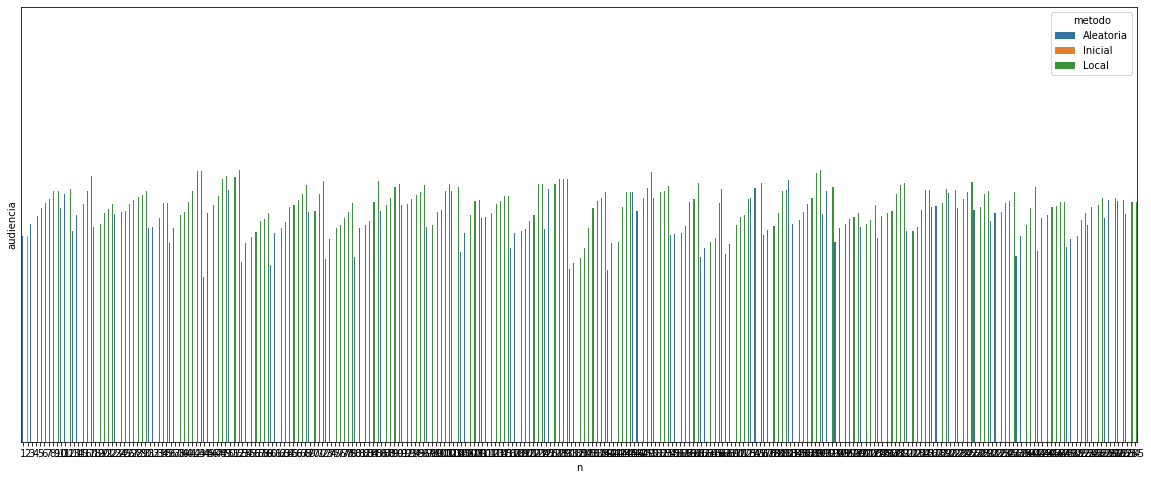

In [239]:
f, ax = plt.subplots(figsize=(20, 8))
plt.xscale('linear')
plt.yscale('log')
ax.set_yscale('symlog', linthreshy=0.5)
ax.grid()
sns.barplot(data = r3,
             x ='n',
             y ='audiencia',
             hue='metodo'
            )
ax.set(ylim=(5, 8))

# Aplica el algoritmo al juego de datos generado

Respuesta: Se aplica el algoritmo de la misma forma del punto anterior.

In [230]:
journey4= generate_maths(teamCategory)
#Presentamos la jornada inicial
print(journey4)

#generamos la solución para la jornada
schedulerJourney4, r4 = simulated_annealing(journey4, schedulePon, T, alpha)

#audiencia 
audiencia4=sum(schedulerJourney4['total'])
print(f'Resultado mejor audiencia potencial: {audiencia4} y el número de iteraciones total fue: {r4.shape[0]}')

#Configuraión de la jornada
display(schedulerJourney4)

                       match category base_m
0  (Valladolid, Real Madrid)   (C, A)      1
1          (Español, Getafe)   (B, B)    0.9
2           (Leganes, Betis)   (C, B)   0.75
3      (Valencia, Barcelona)   (B, A)    1.3
4        (Athletic, Granada)   (B, C)   0.75
5       (Villareal, Osasuna)   (B, C)   0.75
6            (Alaves, Eibar)   (B, C)   0.75
7          (Celta, Mallorca)   (B, C)   0.75
8    (R. Sociedad, Atletico)   (B, A)    1.3
9         (Levante, Sevilla)   (B, B)    0.9
Resultado mejor audiencia potencial: 6.6949999999999985 y el número de iteraciones total fue: 229


,match,category,base_m,id_match,schedule,ponde,base_ponde,concidence,total
0,"(Valladolid, Real Madrid)","(C, A)",1,0,D16,0.75,0.75,1,0.75
1,"(Español, Getafe)","(B, B)",0.9,1,S16,0.70,0.63,1,0.63
2,"(Leganes, Betis)","(C, B)",0.75,2,V20,0.40,0.3,1,0.3
3,"(Valencia, Barcelona)","(B, A)",1.3,3,D20,1.00,1.3,1,1.3
4,"(Athletic, Granada)","(B, C)",0.75,4,D12,0.45,0.3375,1,0.3375
5,"(Villareal, Osasuna)","(B, C)",0.75,5,L20,0.40,0.3,1,0.3
6,"(Alaves, Eibar)","(B, C)",0.75,6,S12,0.55,0.4125,1,0.4125
7,"(Celta, Mallorca)","(B, C)",0.75,7,S18,0.80,0.6,1,0.6
8,"(R. Sociedad, Atletico)","(B, A)",1.3,8,S20,1.00,1.3,1,1.3
9,"(Levante, Sevilla)","(B, B)",0.9,9,D18,0.85,0.765,1,0.765


Graficamos el avance de las soluciones encontradas

[(5.0, 8.0)]

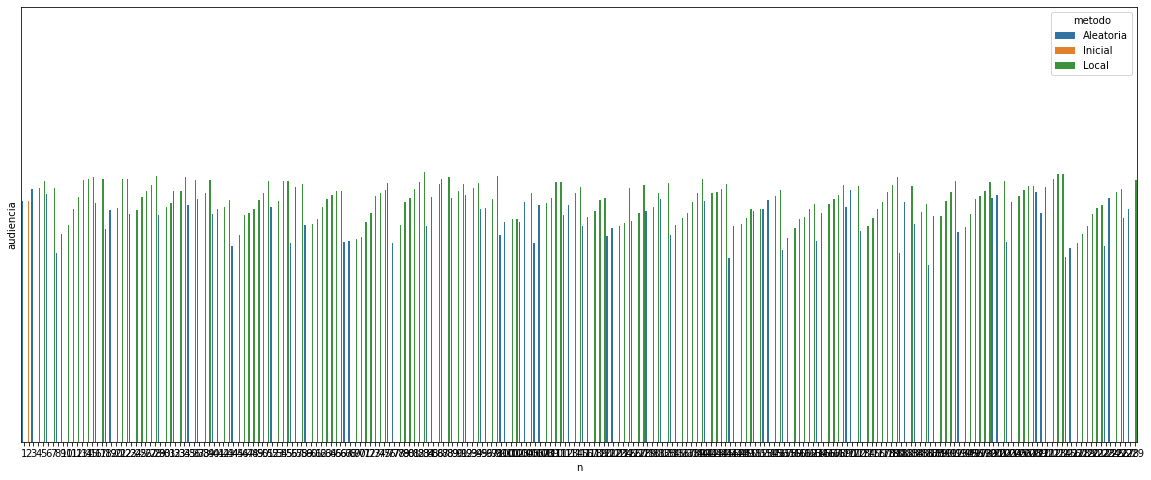

In [240]:
f, ax = plt.subplots(figsize=(20, 8))
plt.xscale('linear')
plt.yscale('log')
ax.set_yscale('symlog', linthreshy=0.5)
ax.grid()
sns.barplot(data = r4,
             x ='n',
             y ='audiencia',
             hue='metodo'
            )
ax.set(ylim=(5, 8))

# Enumera las referencias que has utilizado(si ha sido necesario) para llevar a cabo el trabajo

Respuesta, la referencia utilizadas fue la actividad guiada #3

Describe brevemente las lineas de como crees que es posible avanzar en el estudio del problema. Ten en cuenta incluso posibles variaciones del problema y/o variaciones al alza del tamaño

Respuesta, una opción de mejorar o buscar otras alternativa de solución para el problema puede ser algoritmos geneticos, en el cual se combinen partes de varias soluciones o posiblemente colonia de hormigas.